In [ ]:
#DataFrame
#->2차원 자료구조. 행과 열이 있는 테이블 데이터(Table Data) 처리
#->엑셀
"""
    ● pandas 패키지
      - 데이터 분석용 라이브러리
      - 자료형 : Series(1차원), DataFrame(2차원), Panel(3차원)
        
    ● 모듈설치
      >pip list
      >pip install pandas    
"""

In [1]:
from pandas import DataFrame
from sample2 import grade_list

In [2]:
grade_list

[[98, None, 88, 64],
 [88, 90, 62, 72],
 [92, 70, None, None],
 [63, 60, 31, 70],
 [120, 50, None, 88]]

In [3]:
df = DataFrame(grade_list)
df

,0,1,2,3
0,98,NaN,88.0,64.0
1,88,90.0,62.0,72.0
2,92,70.0,NaN,NaN
3,63,60.0,31.0,70.0
4,120,50.0,NaN,88.0


In [4]:
type(df)

pandas.core.frame.DataFrame

In [5]:
df[0]

0     98
1     88
2     92
3     63
4    120
Name: 0, dtype: int64

In [ ]:
# 컬럼(열) 이름을 지정하여 새로 생성
c_names = ["국어", "영어", "수학", "과학"]

df = DataFrame(grade_list, columns=c_names)
df

,국어,영어,수학,과학
0,98,NaN,88.0,64.0
1,88,90.0,62.0,72.0
2,92,70.0,NaN,NaN
3,63,60.0,31.0,70.0
4,120,50.0,NaN,88.0


In [7]:
# 인덱스(행) 이름을 지정하여 새로 생성
i_names = ['무궁화', '홍길동', "개나리", "진달래", "봉선화"]
df = DataFrame(grade_list, index=i_names)
df

,0,1,2,3
무궁화,98,NaN,88.0,64.0
홍길동,88,90.0,62.0,72.0
개나리,92,70.0,NaN,NaN
진달래,63,60.0,31.0,70.0
봉선화,120,50.0,NaN,88.0


In [8]:
# 인덱스와 컬럼 이름 모두 지정하기
df = DataFrame(grade_list, columns=c_names, index=i_names)
df

,국어,영어,수학,과학
무궁화,98,NaN,88.0,64.0
홍길동,88,90.0,62.0,72.0
개나리,92,70.0,NaN,NaN
진달래,63,60.0,31.0,70.0
봉선화,120,50.0,NaN,88.0


In [9]:
df["국어"]

무궁화     98
홍길동     88
개나리     92
진달래     63
봉선화    120
Name: 국어, dtype: int64

In [10]:
df.loc["무궁화"]

국어    98.0
영어     NaN
수학    88.0
과학    64.0
Name: 무궁화, dtype: float64

In [24]:
print("무궁화의 국어 점수 : %d" % df["국어"].loc["무궁화"])
print("무궁화의 국어 점수 : %d" % df.loc["무궁화", "국어"])

무궁화의 국어 점수 : 98
무궁화의 국어 점수 : 98


In [26]:
"""
-----------------------------------------------
    count 각 열별로 유효한 값의 수
    mean  평균
    std   표준편차
    min   최소값
    max   최대값
    사분위수 : 1사분위 수(하위 25%)
              2사분위 수(중앙값 50%)
              3사분위 수(하위 75%)   ->상위 25%     
--------------------------------------------------
"""

'\n-----------------------------------------------\n    count 각 열별로 유효한 값의 수\n    mean  평균\n    std   표준편차\n    min   최소값\n    max   최대값\n    사분위수 : 1사분위 수(하위 25%)\n              2사분위 수(중앙값 50%)\n              3사분위 수(하위 75%)   ->상위 25%     \n--------------------------------------------------\n'

In [28]:
df.describe()

,국어,영어,수학,과학
count,5.000000,4.000000,3.000000,4.000000
mean,92.200000,67.500000,60.333333,73.500000
std,20.474374,17.078251,28.536526,10.246951
min,63.000000,50.000000,31.000000,64.000000
25%,88.000000,57.500000,46.500000,68.500000
50%,92.000000,65.000000,62.000000,71.000000
75%,98.000000,75.000000,75.000000,76.000000
max,120.000000,90.000000,88.000000,88.000000


In [29]:
print(df.count())
print(df['영어'].count())
print(df['영어'].min())
print(df['영어'].max())
print(df['영어'].sum())
print(df['영어'].std())
print(df['영어'].median())
print(df.quantile(q=0.25))

국어    5
영어    4
수학    3
과학    4
dtype: int64
4
50.0
90.0
270.0
17.07825127659933
65.0
국어    88.0
영어    57.5
수학    46.5
과학    68.5
Name: 0.25, dtype: float64


In [30]:
#데이터 전처리 Data Preprocessing
#->분석에 적합하게 데이터를 가공하는 작업

In [ ]:
#'axis=1' 을 설정하면 각각의 행에 대해 계산함
# NaN은 대상에서 제외
df["평균"] = df.mean(axis=1)
df

,국어,영어,수학,과학,평균
무궁화,98,NaN,88.0,64.0,83.333333
홍길동,88,90.0,62.0,72.0,78.000000
개나리,92,70.0,NaN,NaN,81.000000
진달래,63,60.0,31.0,70.0,56.000000
봉선화,120,50.0,NaN,88.0,86.000000


In [32]:
import numpy as np
#[결과] -> 평균칼럼의 점수가 70점이상이면 합격, 불합격
df["결과"] = np.where(df["평균"] >= 70, "합격", "불합격")
df

,국어,영어,수학,과학,평균,결과
무궁화,98,NaN,88.0,64.0,83.333333,합격
홍길동,88,90.0,62.0,72.0,78.000000,합격
개나리,92,70.0,NaN,NaN,81.000000,합격
진달래,63,60.0,31.0,70.0,56.000000,불합격
봉선화,120,50.0,NaN,88.0,86.000000,합격


In [37]:
#[학점] -> 평균 점수에 따라 A, B, C, D
conditions = [(df["평균"] >= 90), (df["평균"] >= 80), (df["평균"] >= 70), (df["평균"] < 60)]
grade = ["A", "B", "C", "D"]
df["학점"] = np.select(conditions, grade, "F")
df

,국어,영어,수학,과학,평균,결과,학점
무궁화,98,NaN,88.0,64.0,83.333333,합격,B
홍길동,88,90.0,62.0,72.0,78.000000,합격,C
개나리,92,70.0,NaN,NaN,81.000000,합격,B
진달래,63,60.0,31.0,70.0,56.000000,불합격,D
봉선화,120,50.0,NaN,88.0,86.000000,합격,B


In [38]:
# 상자그림 (boxplot)
from matplotlib import pyplot

pyplot.rcParams["font.family"] = 'gulim'
pyplot.rcParams["font.size"]   = 12
pyplot.rcParams["figure.figsize"] = (6, 4)

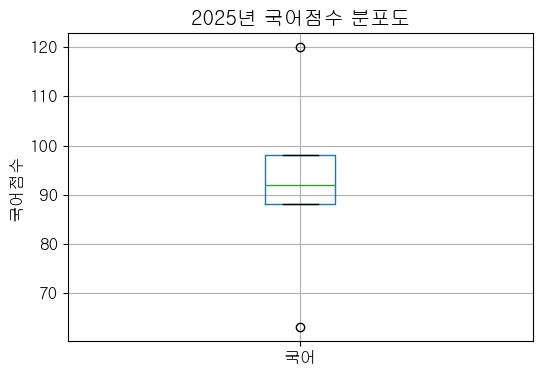

In [39]:
pyplot.figure()
pyplot.grid()
df.boxplot('국어')
pyplot.title("2025년 국어점수 분포도")
pyplot.ylabel("국어점수")
pyplot.show()
pyplot.close()

In [40]:
# 데이터 정제
# -> 결측치 (Missing value) : 누락된 값, 비어 있는 값
# -> 이상치 (Outlier)       : 정상 범주에서 크게 벗어난 값

In [41]:
from sample2 import grade_dic

In [42]:
# 데이터 구성하기
df = DataFrame(grade_dic, index=i_names)
df

,국어,영어,수학,과학
무궁화,98,NaN,88.0,64.0
홍길동,88,90.0,62.0,72.0
개나리,92,70.0,NaN,NaN
진달래,63,60.0,31.0,70.0
봉선화,120,50.0,NaN,88.0


In [44]:
# 결측치 여부 확인
# -> isnull(), isna() 함수
empty = df.isna()
empty

,국어,영어,수학,과학
무궁화,False,True,False,False
홍길동,False,False,False,False
개나리,False,False,True,True
진달래,False,False,False,False
봉선화,False,False,True,False


In [45]:
empty = df.isnull()
empty

,국어,영어,수학,과학
무궁화,False,True,False,False
홍길동,False,False,False,False
개나리,False,False,True,True
진달래,False,False,False,False
봉선화,False,False,True,False


In [47]:
# 국어 점수에 대한 이상치 필터링
r = df.query('국어 > 100')
r

,국어,영어,수학,과학
봉선화,120,50.0,NaN,88.0


In [ ]:
# 국어점수(120) 이상치가 있는 인덱스 값 얻어오기
r_index = list(r.index)
r_index

['봉선화']

In [50]:
# 이상치를 갖는 인덱스에 대한 국어 점수를 결측치로 변경
for i in r_index:
    df.loc[i, '국어'] = np.nan
df

,국어,영어,수학,과학
무궁화,98.0,NaN,88.0,64.0
홍길동,88.0,90.0,62.0,72.0
개나리,92.0,70.0,NaN,NaN
진달래,63.0,60.0,31.0,70.0
봉선화,NaN,50.0,NaN,88.0
